In [1]:
from gnpy.core.parameters import Parameters
from gnpy.core.mmse_pdl import pdl_pen, h_pdl, prod_mat
from gnpy.core.utils import lin2db,db2lin
import numpy as np
import matplotlib.pyplot as plt

def generate_random_numbers(distribution, params, size):  
    def randomvariate(*params, size):
        """  
        Rejection method for random number generation  
        ===============================================  
        Uses the rejection method for generating random numbers derived from an arbitrary   
        probability distribution. For reference, see Bevington's book, page 84. Based on  
        rejection*.py.  
        
        Usage:  
        >>> randomvariate(P,N,xmin,xmax)  
        where  
        P : probability distribution function from which you want to generate random numbers  
        N : desired number of random values  
        xmin,xmax : range of random numbers desired  
            
        Returns:   
        the sequence (ran,ntrials) where  
        ran : array of shape N with the random variates that follow the input P  
        ntrials : number of trials the code needed to achieve N  
        
        Here is the algorithm:  
        - generate x' in the desired range  
        - generate y' between Pmin and Pmax (Pmax is the maximal value of your pdf)  
        - if y'<P(x') accept x', otherwise reject  
        - repeat until desired number is achieved  
        
        """  
        # Calculates the minimal and maximum values of the PDF in the desired interval. 
        # The rejection method needs these values in order to work properly.  
        pdf = params[0]
        xmin = params[1]
        xmax = params[2]

        if isinstance(size,tuple):
            N = 1
            for tmp_N in size:
                N = tmp_N * N
        elif isinstance(size,int):
            N = size

        x = np.linspace(xmin, xmax, 1000)  
        y = pdf(x)  
        pmin = 0.  
        pmax = y.max()  
        
        # Counters  
        naccept = 0  
        ntrial = 0  
        
        # Keeps generating numbers until we achieve the desired n  
        ran = [] # output list of random numbers  
        while naccept < N:  
            x = np.random.uniform(xmin, xmax) # x'  
            y = np.random.uniform(pmin, pmax) # y'  
        
            if y < pdf(x):  
                ran.append(x)  
                naccept = naccept+1  
                ntrial = ntrial+1  
            
        ran = np.asarray(ran)  

        if isinstance(size,tuple):
            ran.reshape(size)
     
        return ran,ntrial    
       
    if distribution == 'uniform':
        return np.random.uniform(*params, size)
    elif distribution == 'normal':
        return np.random.normal(*params, size)
    elif distribution == 'exponential':
        return np.random.exponential(*params, size)
    elif distribution == 'pdf':
        return randomvariate(*params, size)
    else:
        raise ValueError("不支持的分布类型")

def maxwell_distribution(mean_value,x):
    a = mean_value/(2*np.sqrt(2/np.pi))
    return np.sqrt(2/np.pi)*x**2/(a**3)*np.exp(-(x**2)/(2*a**2))

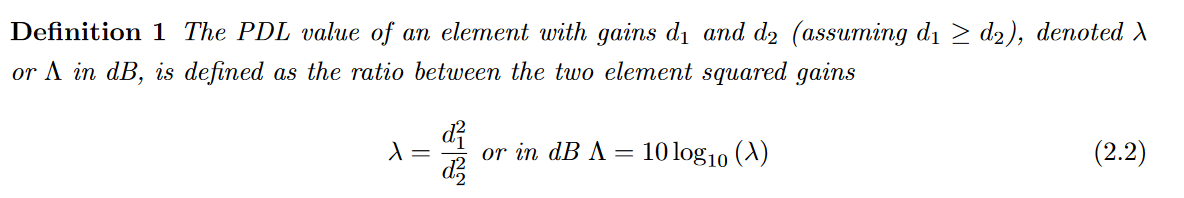

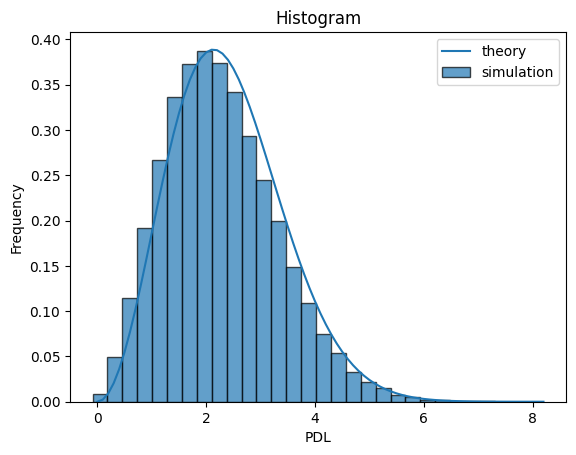

In [5]:
N_sim = 100000
N_pdl = 10
pdl_tot_dB = np.zeros(N_sim)
for i in range(N_sim):
    pdl = generate_random_numbers(distribution='normal',params=(0.4,0.1),size=N_pdl)
    alpha = generate_random_numbers(distribution='uniform',params=(0,2*np.pi),size=N_pdl)
    beta = generate_random_numbers(distribution='uniform',params=(0,2*np.pi),size=N_pdl)
    h_pdl_list = []
    for j in range(N_pdl):
        h_pdl_list.append(h_pdl(pdl_dB=pdl[j],alpha=alpha[j],beta=beta[j]))

    h_pdl_tot = prod_mat(h_pdl_list)
    U, S, Vt = np.linalg.svd(h_pdl_tot)
    pdl_tot_dB[i] = 2*lin2db(S[0]/S[1])

mean_value = np.mean(pdl_tot_dB)
x = np.arange(0,np.max(pdl_tot_dB),0.1)
y = maxwell_distribution(mean_value,x)


hist, bin_edges = np.histogram(pdl_tot_dB, bins=30, density=True)
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="k", alpha=0.7,label='simulation')
plt.plot(x,y,label='theory')
plt.xlabel('PDL')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.legend()
plt.show()